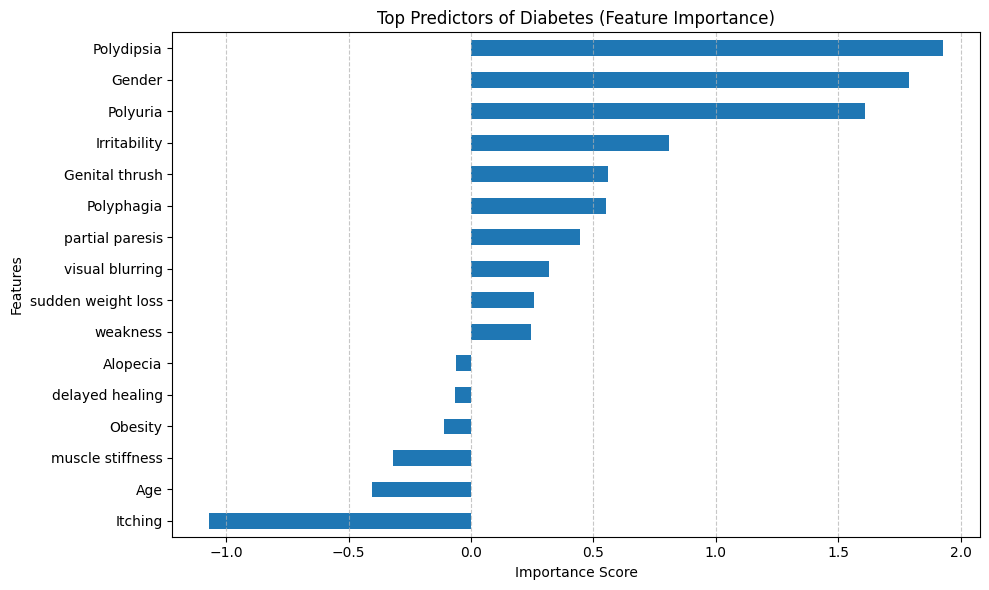

Top predictors of diabetes:
Itching              -1.069229
Age                  -0.403124
muscle stiffness     -0.318479
Obesity              -0.111935
delayed healing      -0.063528
Alopecia             -0.061075
weakness              0.246558
sudden weight loss    0.255456
visual blurring       0.317094
partial paresis       0.447266
Polyphagia            0.551056
Genital thrush        0.557659
Irritability          0.809419
Polyuria              1.610607
Gender                1.787606
Polydipsia            1.928797
dtype: float64

Saved files:
outputs\feature_importance.csv
outputs\feature_importance_chart.png


In [1]:
#Feature Importance Chart (Top Predictors of Diabetes) using Logistic regression
#File Created by Hema Dawonauth
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# -----------------------------
# Reproducibility settings
# -----------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -----------------------------
# File paths
# -----------------------------
DATA_PATH = Path("../03_data/raw/diabetes_data_upload.csv")
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv(DATA_PATH).copy()

# Clean column names
df.columns = df.columns.str.strip()

# -----------------------------
# Encode target variable
# -----------------------------
df["class"] = df["class"].map({"Negative": 0, "Positive": 1})

# -----------------------------
# Encode categorical variables
# -----------------------------
binary_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 0, "Female": 1}

# Encode Yes/No columns
object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    if col != "Gender" and col != "class":
        df[col] = df[col].map(binary_map)

# Encode Gender
df["Gender"] = df["Gender"].map(gender_map)

# -----------------------------
# Validate data
# -----------------------------
if df.isnull().sum().sum() > 0:
    raise ValueError("Dataset contains missing values after encoding. Please clean the data first.")

# -----------------------------
# Features and target
# -----------------------------
X = df.drop(columns=["class"])
y = df["class"]

# -----------------------------
# Fixed train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# -----------------------------
# Reproducible model pipeline
# -----------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

model.fit(X_train, y_train)

# -----------------------------
# Extract feature importance
# -----------------------------
coef = model.named_steps["logreg"].coef_[0]
importance = pd.Series(coef, index=X.columns).sort_values()

# Save importance to CSV
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", header=["importance_score"])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))
importance.plot(kind="barh")

plt.title("Top Predictors of Diabetes (Feature Importance)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()

# Save figure for reproducibility
plt.savefig(OUTPUT_DIR / "feature_importance_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Print results
# -----------------------------
print("Top predictors of diabetes:")
print(importance)

print("\nSaved files:")
print(OUTPUT_DIR / "feature_importance.csv")
print(OUTPUT_DIR / "feature_importance_chart.png")

C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\2179517911.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)


Model AUC: 1.0
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        46
           1       1.00      0.99      0.99        84

    accuracy                           0.99       130
   macro avg       0.99      0.99      0.99       130
weighted avg       0.99      0.99      0.99       130


Risk distribution age ≥40
risk_group
High      235
Low       137
Medium      4
Name: count, dtype: int64


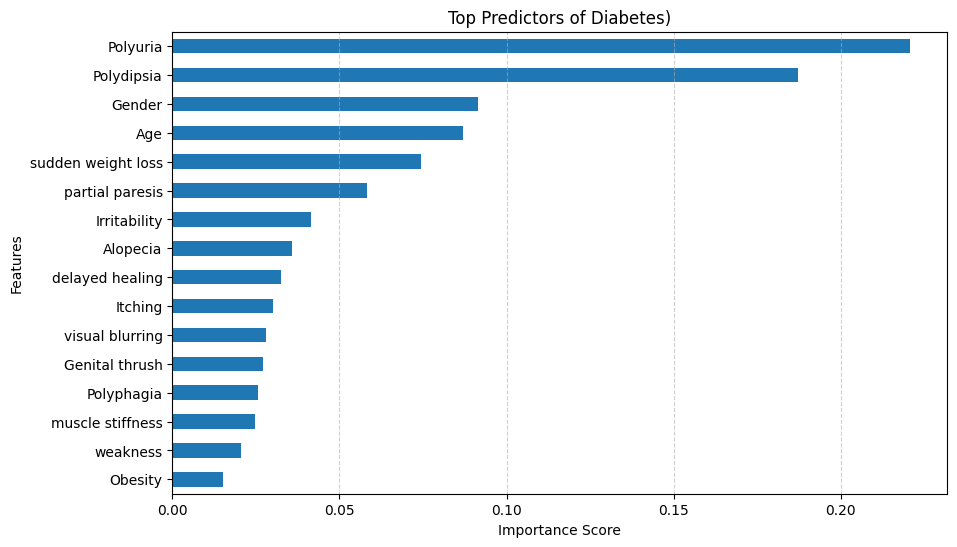

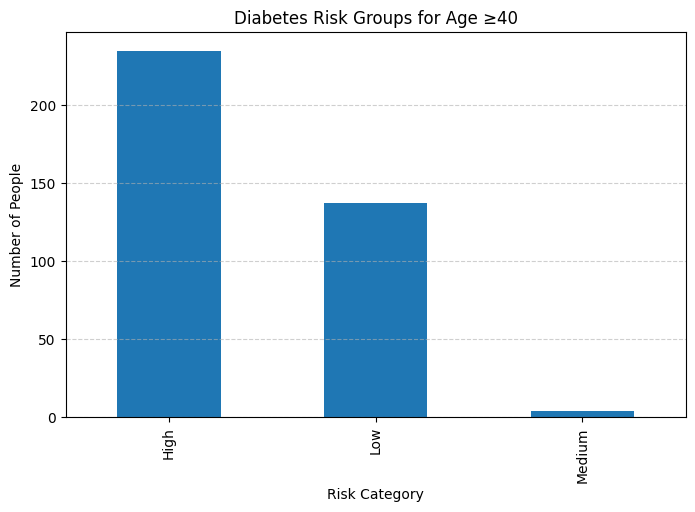

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Top Predictors of Diabtes using Random Forest

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# =========================
# 1 Load Dataset
# =========================
df = pd.read_csv("../03_data/raw/diabetes_data_upload.csv")

# Convert target
df['class'] = df['class'].map({'Negative':0,'Positive':1})

# Encode gender
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})

# Convert Yes/No symptoms
binary_map = {"Yes":1,"No":0}

symptom_cols = [c for c in df.columns if c not in ['Age','Gender','class']]
df[symptom_cols] = df[symptom_cols].replace(binary_map)

# =========================
# 2 Features / Target
# =========================
X = df[['Age','Gender'] + symptom_cols]
y = df['class']

# Train test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.25,random_state=42
)

# =========================
# 3 Train Random Forest
# =========================
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=RANDOM_STATE
)

model.fit(X_train,y_train)

# =========================
# 4 Evaluate Model
# =========================
pred_prob = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test,pred_prob)

print("Model AUC:",auc)
print(classification_report(y_test,model.predict(X_test)))

# =========================
# 5 Predict Risk for Dataset
# =========================
df['risk_probability'] = model.predict_proba(X)[:,1]

# =========================
# 6 Risk Stratification
# =========================
def risk_category(p):
    if p < 0.30:
        return "Low"
    elif p < 0.60:
        return "Medium"
    else:
        return "High"

df['risk_group'] = df['risk_probability'].apply(risk_category)

# =========================
# 7 Focus on Population >=40
# =========================
over40 = df[df['Age'] >= 40]

risk_counts = over40['risk_group'].value_counts()

print("\nRisk distribution age ≥40")
print(risk_counts)

# =========================
# 8 Feature Importance
# =========================
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

# =========================
# 9 Plot Feature Importance
# =========================
plt.figure(figsize=(10,6))

importance.plot(kind='barh')

plt.title("Top Predictors of Diabetes)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.show()

# =========================
# 10 Risk Distribution Chart
# =========================
plt.figure(figsize=(8,5))

risk_counts.plot(kind='bar')

plt.title("Diabetes Risk Groups for Age ≥40")
plt.xlabel("Risk Category")
plt.ylabel("Number of People")

plt.grid(axis='y',linestyle='--',alpha=0.6)
plt.show()

C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\3794862345.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\3794862345.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace(gender_map)
C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\3794862345.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

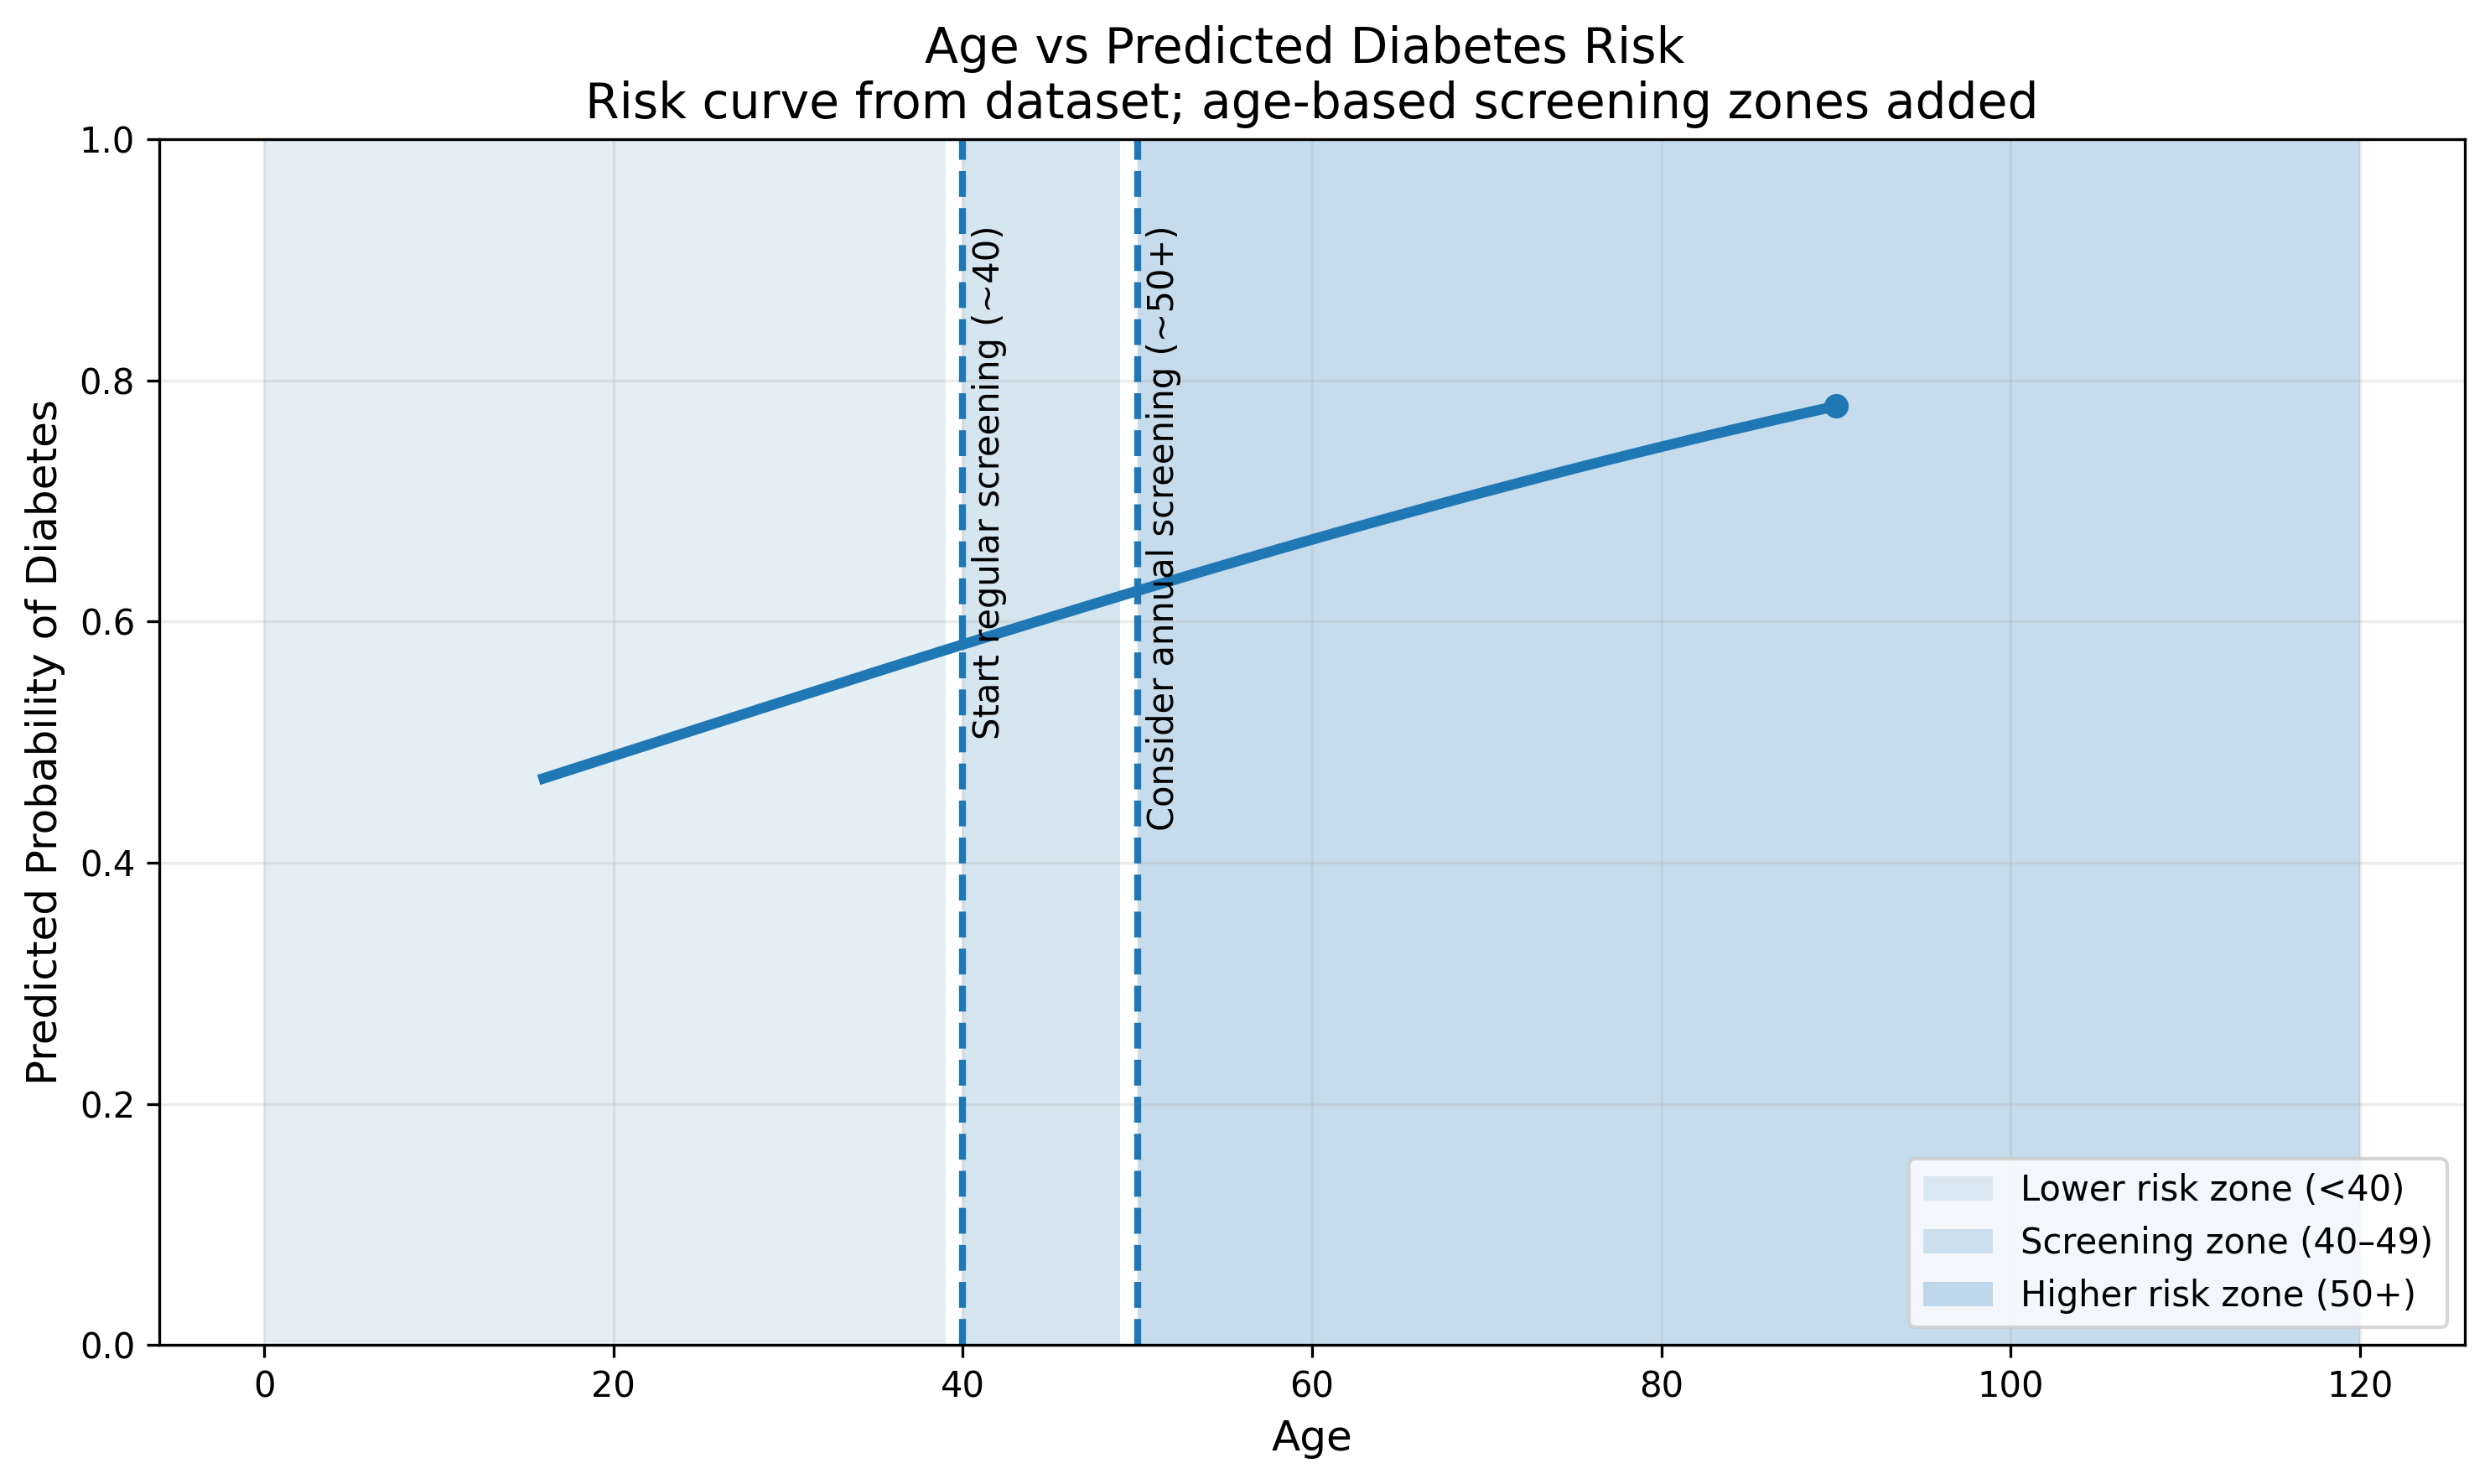

Saved: outputs\age_vs_diabetes_risk.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# =========================
# 1) Load + preprocess data
# =========================
df = pd.read_csv("../03_data/raw/diabetes_data_upload.csv")

binary_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

symptom_cols = df.columns.drop(["Age", "Gender", "class"])
df[symptom_cols] = df[symptom_cols].replace(binary_map)
df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)

# =========================
# 2) Fit Age-only risk model
# =========================
X = df[["Age"]]
y = df["class"]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])
model.fit(X, y)

# =========================
# 3) Predict risk by age
# =========================
ages = np.arange(int(df["Age"].min()), int(df["Age"].max()) + 1)
risk = model.predict_proba(pd.DataFrame({"Age": ages}))[:, 1]

# Highest-risk point (within dataset age range)
max_idx = int(np.argmax(risk))
max_age = int(ages[max_idx])
max_risk = float(risk[max_idx])

# =========================
# 4) Clinic-ready plot
# =========================
plt.figure(figsize=(10, 6), dpi=300)

# Risk zones (customize if you want)
# Here we use AGE zones (simple & easy for clinics)
plt.axvspan(0, 39, alpha=0.12, label="Lower risk zone (<40)")
plt.axvspan(40, 49, alpha=0.18, label="Screening zone (40–49)")
plt.axvspan(50, 120, alpha=0.25, label="Higher risk zone (50+)")

# Risk curve
plt.plot(ages, risk, linewidth=3)

# Screening guideline lines (customize)
screen_start = 40
annual_start = 50
plt.axvline(screen_start, linestyle="--", linewidth=2)
plt.axvline(annual_start, linestyle="--", linewidth=2)

# Annotate guideline lines
y_top = min(0.98, max_risk + 0.15)  # keep text in frame
plt.text(screen_start + 0.5, y_top, "Start regular screening (~40)", rotation=90, va="top", fontsize=10)
plt.text(annual_start + 0.5, y_top, "Consider annual screening (~50+)", rotation=90, va="top", fontsize=10)

# Highlight highest-risk point
plt.scatter([max_age], [max_risk], zorder=5)


# Titles + labels
plt.title("Age vs Predicted Diabetes Risk \nRisk curve from dataset; age-based screening zones added", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Predicted Probability of Diabetes", fontsize=12)
plt.ylim(0, 1)

# A light grid helps reading
plt.grid(alpha=0.25)

# Legend
plt.legend(loc="lower right", frameon=True)

plt.tight_layout()

# Save
OUTPUT_DIR = Path("./outputs")
out_path =  OUTPUT_DIR / "age_vs_diabetes_risk.png"
plt.savefig(out_path)
plt.show()

print("Saved:", out_path)

C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\2044293852.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\2044293852.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Gender"] = df["Gender"].replace(gender_map)
C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\2044293852.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

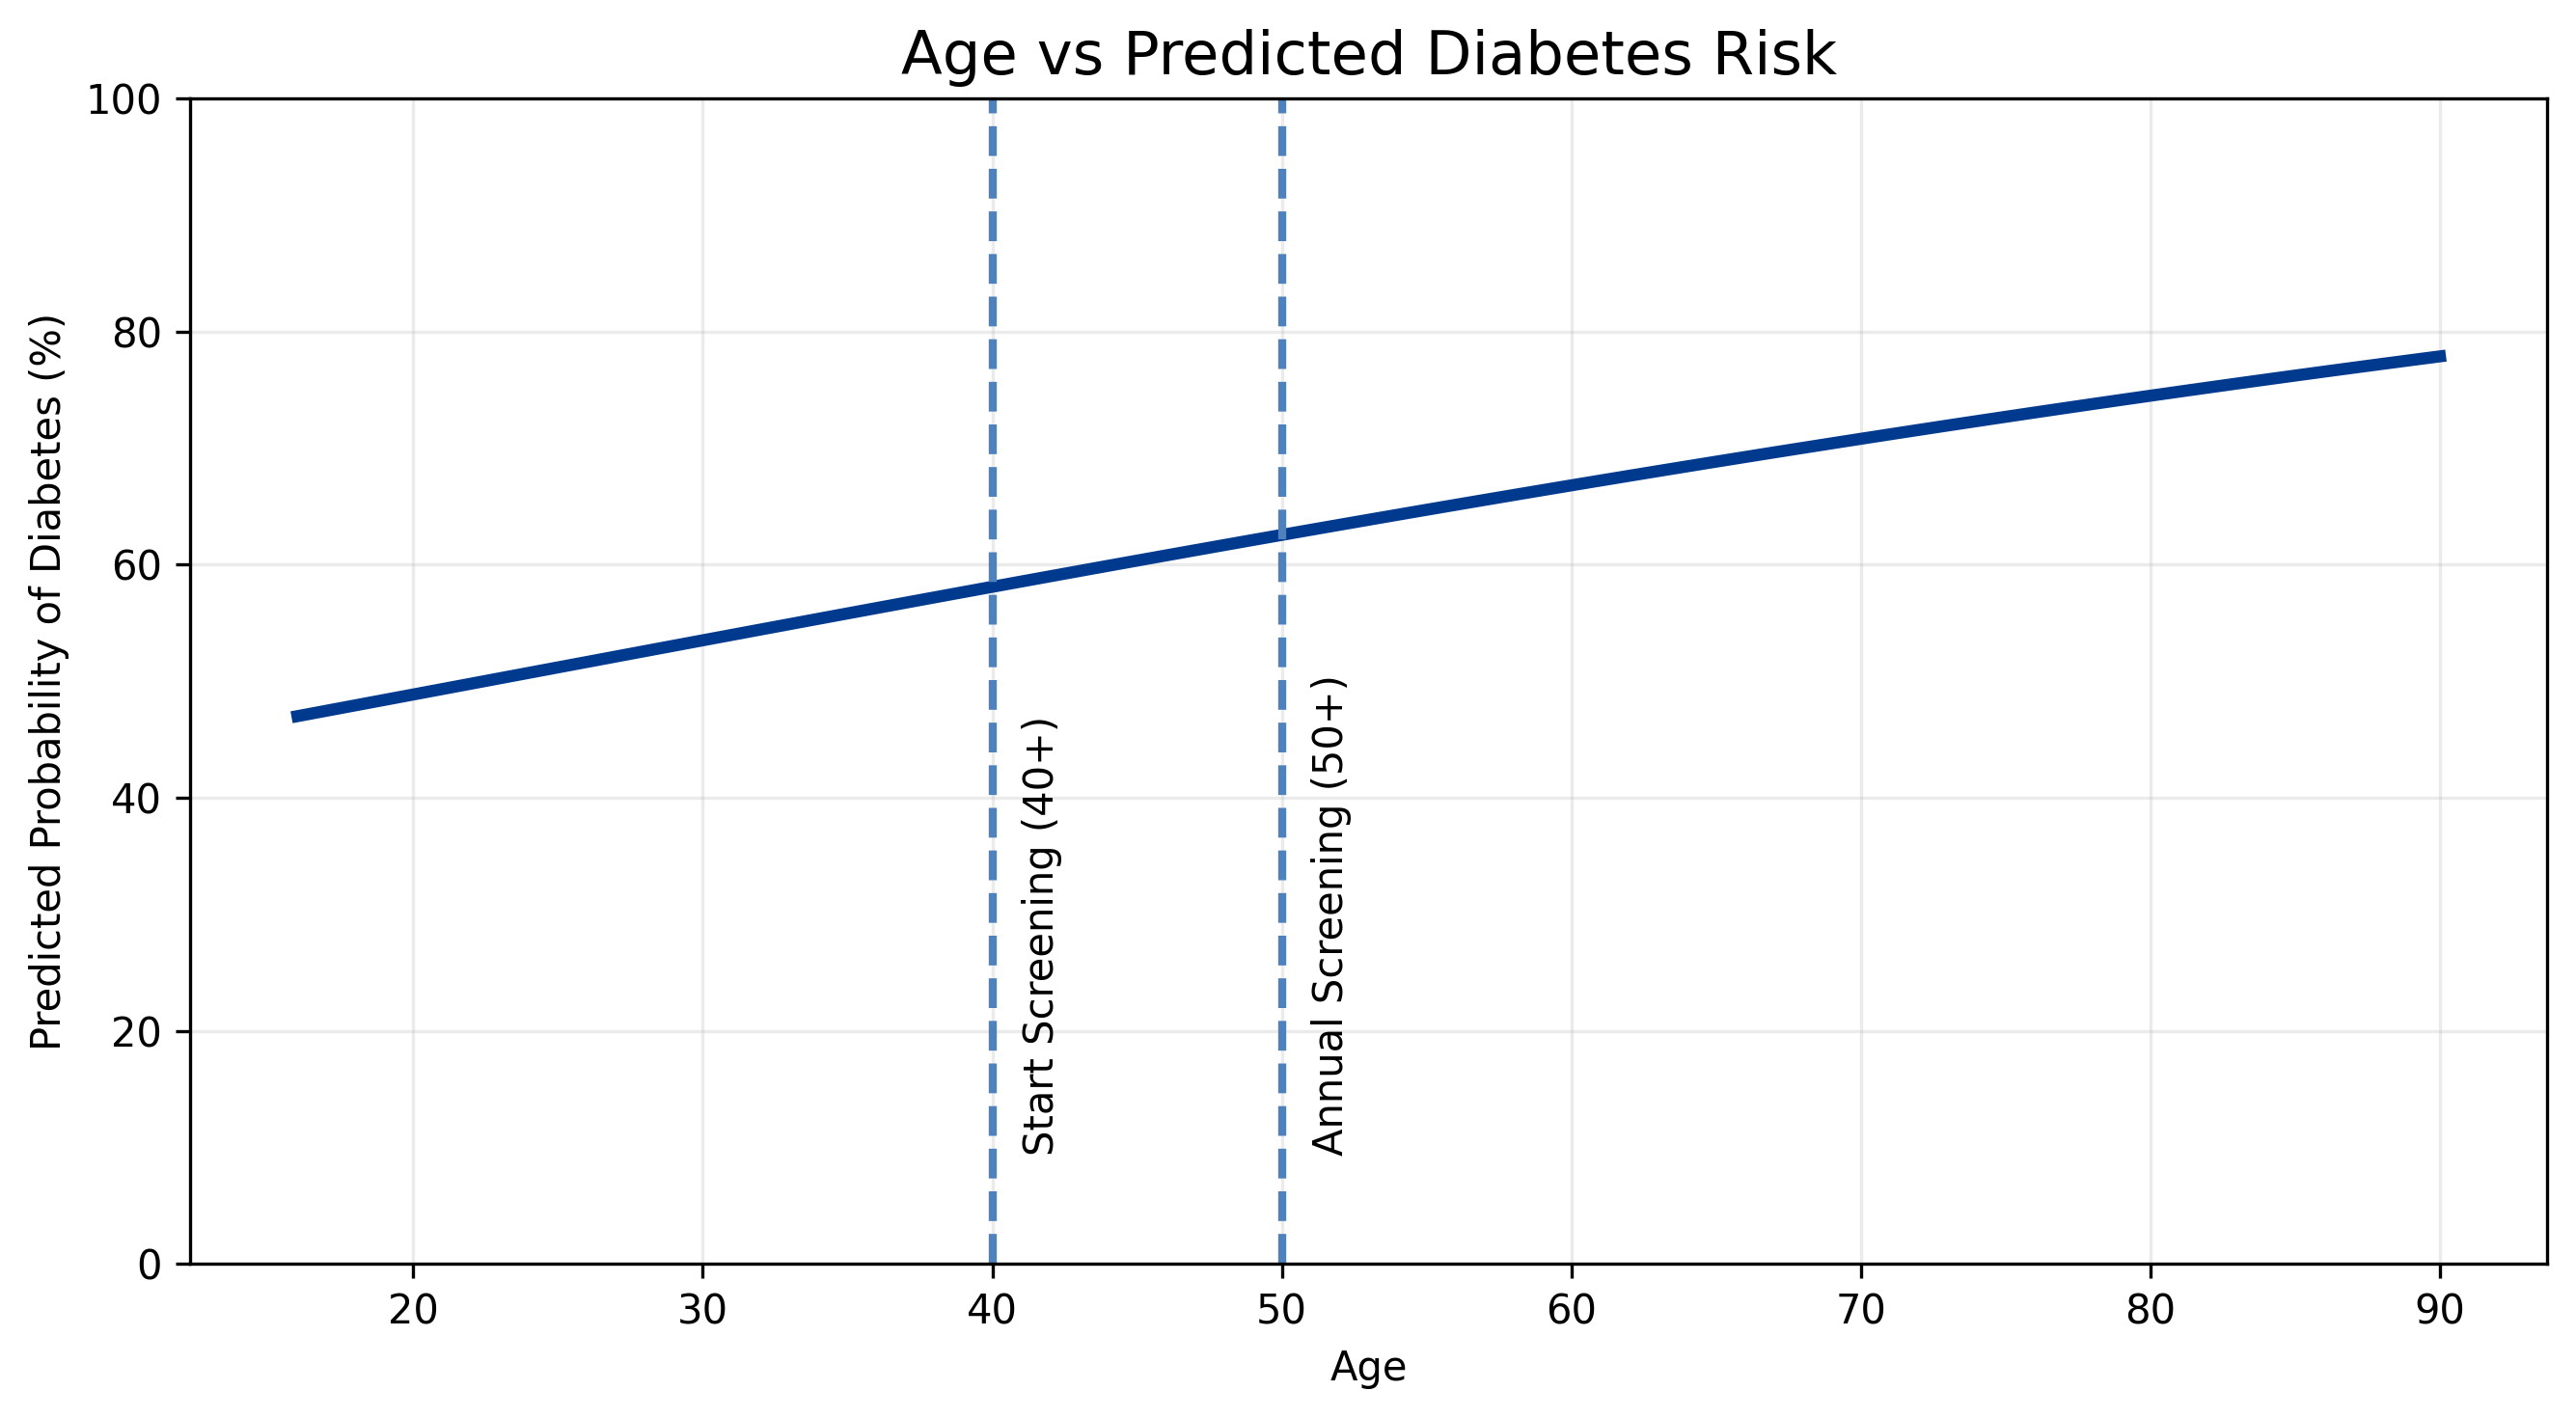

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Load dataset
df = pd.read_csv("../03_data/raw/diabetes_data_upload.csv")

# 2. Encode categorical variables
binary_map = {"Yes": 1, "No": 0}
gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

symptom_cols = df.columns.drop(["Age", "Gender", "class"])

df[symptom_cols] = df[symptom_cols].replace(binary_map)
df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)

# 3. Train model using Age
X = df[["Age"]]
y = df["class"]

model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

model.fit(X, y)

# 4. Predict risk across ages
ages = np.arange(df["Age"].min(), df["Age"].max() + 1)
age_grid = pd.DataFrame({"Age": ages})

risk = model.predict_proba(age_grid)[:,1]

# Ontario Public Health color palette
ontario_blue = "#003A8F"
ontario_light_blue = "#4F81BD"

# Screening markers
screening_age = 40
annual_screening = 50


# 5. Plot
plt.figure(figsize=(9,5), dpi=300)

plt.plot(ages, risk *100, color=ontario_blue, linewidth=3)

# Screening markers
plt.axvline(screening_age, linestyle="--", color=ontario_light_blue, linewidth=2)
plt.axvline(annual_screening, linestyle="--", color=ontario_light_blue, linewidth=2)

# Marker labels
plt.text(screening_age+1, 10, "Start Screening (40+)", rotation=90)
plt.text(annual_screening+1, 10, "Annual Screening (50+)", rotation=90)

# Labels
plt.title("Age vs Predicted Diabetes Risk", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Predicted Probability of Diabetes (%)")

plt.ylim(0,100)
plt.grid(alpha=0.25)

plt.tight_layout()

# Save
plt.savefig(OUTPUT_DIR /"ontario_diabetes_risk_curve.png")

plt.show()




In [6]:
import pandas as pd
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score


# -----------------------------
# 1. Load dataset
# -----------------------------
DATA_PATH = "../03_data/raw/diabetes_data_upload.csv"   # update if needed
MODEL_DIR = Path("./model_artifacts")
MODEL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)

# Expected columns in the dataset:
# Age, Gender, Polyuria, Polydipsia, sudden weight loss, weakness,
# Polyphagia, Genital thrush, visual blurring, Itching, Irritability,
# delayed healing, partial paresis, muscle stiffness, Alopecia, Obesity, class

# -----------------------------
# 2. Basic cleanup
# -----------------------------
df.columns = [col.strip() for col in df.columns]

# Standardize text values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

# Target mapping
target_col = "class"
df[target_col] = df[target_col].replace({
    "Positive": 1,
    "Negative": 0
})

# -----------------------------
# 3. Define features
# -----------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

categorical_features = [col for col in X.columns if X[col].dtype == "object"]
numeric_features = [col for col in X.columns if X[col].dtype != "object"]

# -----------------------------
# 4. Preprocessing
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# -----------------------------
# 5. Model pipeline
# -----------------------------
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# -----------------------------
# 6. Train / test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 7. Train model
# -----------------------------
model.fit(X_train, y_train)

# -----------------------------
# 8. Evaluate model
# -----------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 9. Save model and feature list
# -----------------------------
joblib.dump(model, MODEL_DIR / "diabetes_risk_model.pkl")
joblib.dump(list(X.columns), MODEL_DIR / "feature_columns.pkl")

print("\nModel saved to:", MODEL_DIR / "diabetes_risk_model.pkl")
print("Feature list saved to:", MODEL_DIR / "feature_columns.pkl")

Accuracy: 0.9327
ROC-AUC : 0.9902

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.97      0.92        40
           1       0.98      0.91      0.94        64

    accuracy                           0.93       104
   macro avg       0.92      0.94      0.93       104
weighted avg       0.94      0.93      0.93       104


Model saved to: model_artifacts\diabetes_risk_model.pkl
Feature list saved to: model_artifacts\feature_columns.pkl


C:\Users\h_daw\AppData\Local\Temp\ipykernel_15444\3237923077.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_col] = df[target_col].replace({


In [2]:
import joblib
import pandas as pd
import streamlit as st
from pathlib import Path

# -----------------------------
# Page config
# -----------------------------
st.set_page_config(
    page_title="Diabetes Risk Predictor",
    page_icon="🩺",
    layout="centered"
)

st.title("🩺 Diabetes Risk Predictor")
st.write(
    "Enter age, sex, and symptoms to estimate whether a person is at "
    "low risk or high risk for diabetes."
)

# -----------------------------
# Load model
# -----------------------------
MODEL_DIR = Path("./model_artifacts")
model_path = MODEL_DIR / "diabetes_risk_model.pkl"
feature_path = MODEL_DIR / "feature_columns.pkl"

if not model_path.exists() or not feature_path.exists():
    st.error("Model files not found. Please run train_diabetes_model.py first.")
    st.stop()

model = joblib.load(model_path)
feature_columns = joblib.load(feature_path)

# -----------------------------
# Helper
# -----------------------------
def yes_no_input(label: str) -> str:
    return st.selectbox(label, ["No", "Yes"])

# -----------------------------
# User inputs
# -----------------------------
st.subheader("Patient Information")

age = st.number_input("Age", min_value=1, max_value=120, value=45, step=1)
gender = st.selectbox("Gender", ["Male", "Female"])

st.subheader("Symptoms")

polyuria = yes_no_input("Polyuria (frequent urination)")
polydipsia = yes_no_input("Polydipsia (excessive thirst)")
sudden_weight_loss = yes_no_input("Sudden weight loss")
weakness = yes_no_input("Weakness")
polyphagia = yes_no_input("Polyphagia (increased hunger)")
genital_thrush = yes_no_input("Genital thrush")
visual_blurring = yes_no_input("Visual blurring")
itching = yes_no_input("Itching")
irritability = yes_no_input("Irritability")
delayed_healing = yes_no_input("Delayed healing")
partial_paresis = yes_no_input("Partial paresis")
muscle_stiffness = yes_no_input("Muscle stiffness")
alopecia = yes_no_input("Alopecia")
obesity = yes_no_input("Obesity")

# -----------------------------
# Build input record
# -----------------------------
input_dict = {
    "Age": age,
    "Gender": gender,
    "Polyuria": polyuria,
    "Polydipsia": polydipsia,
    "sudden weight loss": sudden_weight_loss,
    "weakness": weakness,
    "Polyphagia": polyphagia,
    "Genital thrush": genital_thrush,
    "visual blurring": visual_blurring,
    "Itching": itching,
    "Irritability": irritability,
    "delayed healing": delayed_healing,
    "partial paresis": partial_paresis,
    "muscle stiffness": muscle_stiffness,
    "Alopecia": alopecia,
    "Obesity": obesity
}

# Ensure exact training column order
input_df = pd.DataFrame([input_dict])

# Add any missing columns if needed
for col in feature_columns:
    if col not in input_df.columns:
        input_df[col] = None

# Keep only expected columns, in order
input_df = input_df[feature_columns]

# -----------------------------
# Prediction threshold
# -----------------------------
RISK_THRESHOLD = 0.50

# -----------------------------
# Predict
# -----------------------------
if st.button("Predict Risk"):
    probability = model.predict_proba(input_df)[0][1]
    prediction = "High Risk" if probability >= RISK_THRESHOLD else "Low Risk"

    st.subheader("Prediction Result")

    if prediction == "High Risk":
        st.error(f"Prediction: {prediction}")
    else:
        st.success(f"Prediction: {prediction}")

    st.metric("Predicted Probability of Diabetes", f"{probability * 100:.1f}%")

    st.write("### Interpretation")
    if probability >= 0.75:
        st.write("This person appears to have a very elevated diabetes risk based on the model.")
    elif probability >= 0.50:
        st.write("This person appears to have an elevated diabetes risk based on the model.")
    elif probability >= 0.25:
        st.write("This person appears to have a moderate diabetes risk based on the model.")
    else:
        st.write("This person appears to have a lower diabetes risk based on the model.")

    st.warning(
        "This tool is for educational screening support only and is not a medical diagnosis. "
        "A healthcare professional should evaluate any symptoms or concerns."
    )

# -----------------------------
# Optional: show input
# -----------------------------
with st.expander("Show entered data"):
    st.dataframe(input_df)

ModuleNotFoundError: No module named 'streamlit'